# Explore here

In [19]:
#Librerias

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Paso 1: Carga del conjunto de datos

In [20]:
df = pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=927&path=AB_NYC_2019.csv')

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [21]:
df.to_csv('../data/raw/datos_airbnb_nyc.csv', index=False)

## Paso 2: Realiza un EDA completo

### Paso 1 EDA:
### Planteamiento del problema y recopilación de datos

Problema: Predicción de precios en NYC para Airbnb

### Paso 2 EDA:

### Exploración y limpieza de datos

In [22]:
#Obtener información de tipos de datos y valores nulos de cada columna
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

- Tenemos 48.895 filas y 16 columnas.

- También podemos observar que tenemos muchos valores nulos en las columnas name, host_name, last_review y reviews_per_month.

- En los tipos de datos podemos inferir que tenemos 10 variables numéricas y 6 categóricas. 

Ahora procedemos a analizar si tenemos duplicados y en caso de que hubiera, eliminarlos.

In [23]:
#Analizar si hay duplicados restando una columna específica (id)
print(df.drop(columns=['id']).duplicated().sum())

#Analizar si en una columna específica hay duplicados (id)
print(df['id'].duplicated().sum())

#Analizar cantidad total de duplicados, todas las columnas
print(df.duplicated().sum())

0
0
0


Luego de este breve análisis, podemos concluir que no hay duplicados.

A continuación, vamos a eliminar la información irrelevante.

In [24]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

In [25]:
df.drop(['id', 'name', 'host_id', 'host_name', 'last_review', 'reviews_per_month'],axis=1,inplace=True)

df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,1,0


Argumentos

- Las columnas id y host_id no son relevantes para el precio, dado que son identificadores.
- Las columnas name y host_name no son relevantes para el precio, ya que no nos ayuda a definir la propiedad.
- La columna last_review no es relevante para el precio porque es un dato anecdótico.
- La columna reviews_per_month tiene casi la misma información que number_of_reviews, solo que dividido por 12. 

### Paso 3 EDA:

### Análisis de variables univariante

- ***Analisis de variables categóricas***

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  str    
 1   neighbourhood                   48895 non-null  str    
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  str    
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   calculated_host_listings_count  48895 non-null  int64  
 9   availability_365                48895 non-null  int64  
dtypes: float64(2), int64(5), str(3)
memory usage: 5.3 MB


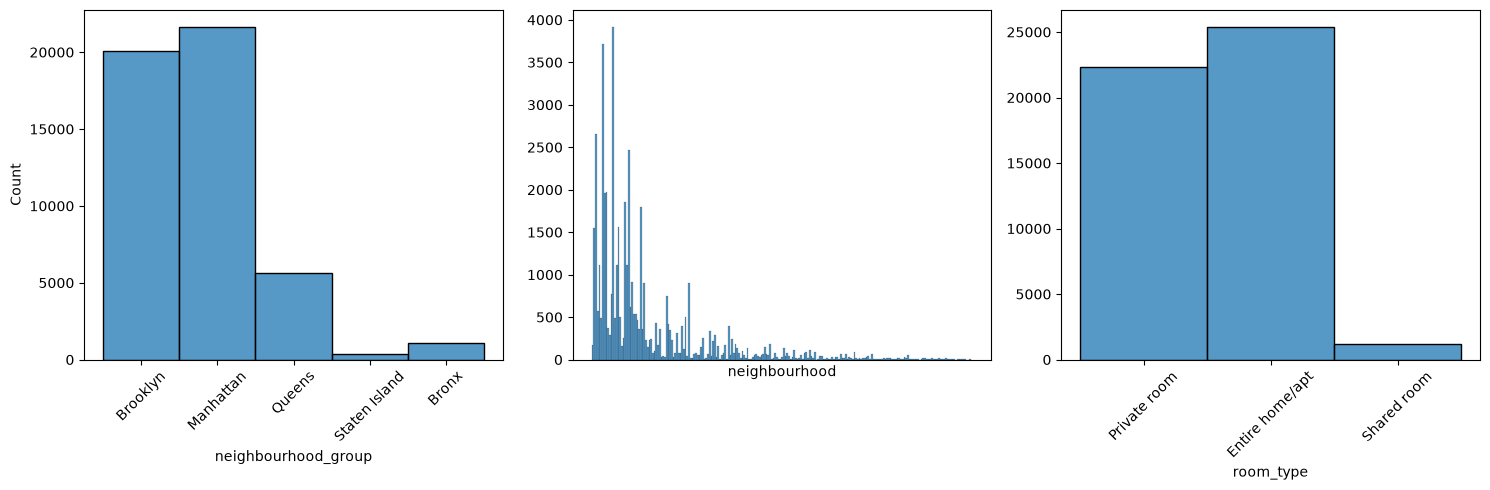

In [27]:
fig, axis = plt.subplots(1,3, figsize=(15,5))

#Histogramas
sns.histplot(ax = axis[0], data = df, x = 'neighbourhood_group')
axis[0].tick_params(axis='x', rotation=45)
sns.histplot(ax = axis[1], data = df, x = 'neighbourhood').set_xticks([])
axis[1].set(ylabel=None)
sns.histplot(ax = axis[2], data = df, x = 'room_type').set(ylabel=None)
axis[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Analizando los histogramas podemos determinar que:

- A partir del primer gráfico concluimos que Manhattan es el neighbourhood_group que más lugares tiene para arrendamiento en Airbnb, seguido de cerca por Brooklyn, ambos sobre 20.000 cada uno y ya luego baja notablemente.
- A partir del segundo gráfico podemos inferir que hay algunos neighbourhoods que tienen muchísimos más lugares en comparación a muchos que tienen pocos lugares.
- Del tercer gráfico podemos concluir que el Shared Room es el tipo de habitación que menor cantidad de lugares tiene, mientras que un Private Room y un Entire Home/Apt tienen ambos sobre 20.000 cada uno, siendo Entire Home/Apt con la mayoría.


- ***Analisis de variables numéricas***

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  str    
 1   neighbourhood                   48895 non-null  str    
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  str    
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   calculated_host_listings_count  48895 non-null  int64  
 9   availability_365                48895 non-null  int64  
dtypes: float64(2), int64(5), str(3)
memory usage: 5.3 MB


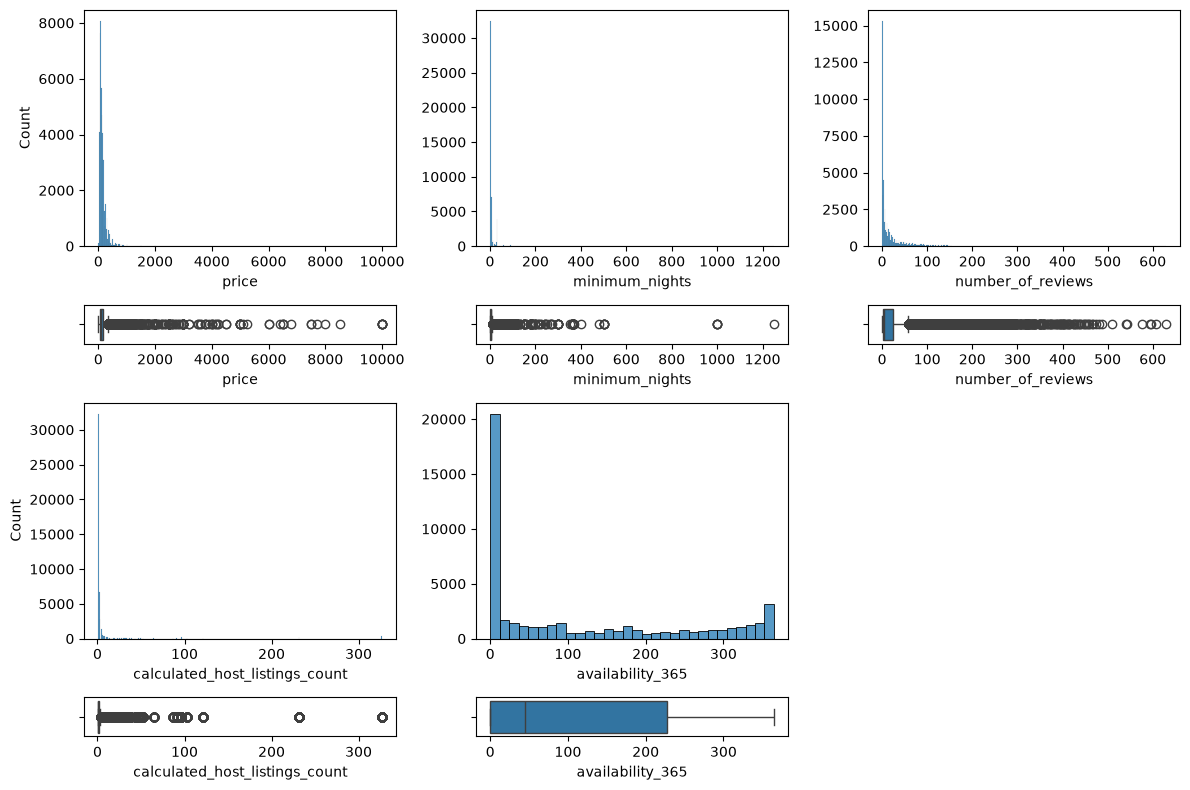

In [38]:
fig, axis = plt.subplots(4,3, figsize=(12,8),gridspec_kw= {"height_ratios":[6,1,6,1]})

sns.histplot(ax = axis[0,0], data = df, x = 'price')
sns.boxplot(ax = axis[1,0], data = df, x = 'price')

sns.histplot(ax = axis[0,1],data = df, x = 'minimum_nights').set(ylabel=None)
sns.boxplot(ax = axis[1,1], data = df, x = 'minimum_nights')

sns.histplot(ax = axis[0,2],data = df, x = 'number_of_reviews').set(ylabel=None)
sns.boxplot(ax = axis[1,2], data = df, x = 'number_of_reviews')

sns.histplot(ax = axis[2,0],data = df, x = 'calculated_host_listings_count')
sns.boxplot(ax = axis[3,0], data = df, x = 'calculated_host_listings_count')

sns.histplot(ax = axis[2,1],data = df, x = 'availability_365').set(ylabel=None)
sns.boxplot(ax = axis[3,1], data = df, x = 'availability_365')

fig.delaxes(axis[2,2])
fig.delaxes(axis[3,2])

plt.tight_layout()
plt.show()

Analizando los gráficos podemos determinar que:

- En todos los gráficos podemos observar una enorme cantidad de ceros.
- A partir del primer gráfico concluimos que la mayoria de los precios se agrupa hasta los $500 pero sin embargo hay airbnb que llegan a valores de $10000 de arriendo.
- A partir del segundo gráfico podemos inferir que la mayoria no tiene requerimiento un número mínimo de noches, sin embargo hay algunos valores atípicos que muestran que hay airbnbs que piden sobre 1200 como mínimo, lo cual puede significar un error del ingreso de los datos.
- Del tercer gráfico podemos concluir que la mayoría de las propiedades en airbnb se concentra entre 0 a 25 reseñas aprox, teniendo muchos valores atípicos, los cuales llegan hasta más de 600 reseñas.
- Del cuatro gráfico concluimos que la amplia mayoria de los anfitriones de airbnb tienen solo una propiedad, mientras que algunos tienen hasta 50 propiedades. Algunos valores atípicos escapan sobre las 200 propiedades.
- Y finalmente del quinto gráfico podemos inferir que más de 20.000 propiedades tienen una disponibilidad cercana a 0 días del año, cerca de 2500 propiedades tienen una disponibilidad de casi todo el año, mientras que el resto tiene una distribución más uniforme.

### Paso 4 EDA:

### Análisis de variables multivariante

- ***Análisis multivariante Numérico - Numérico***

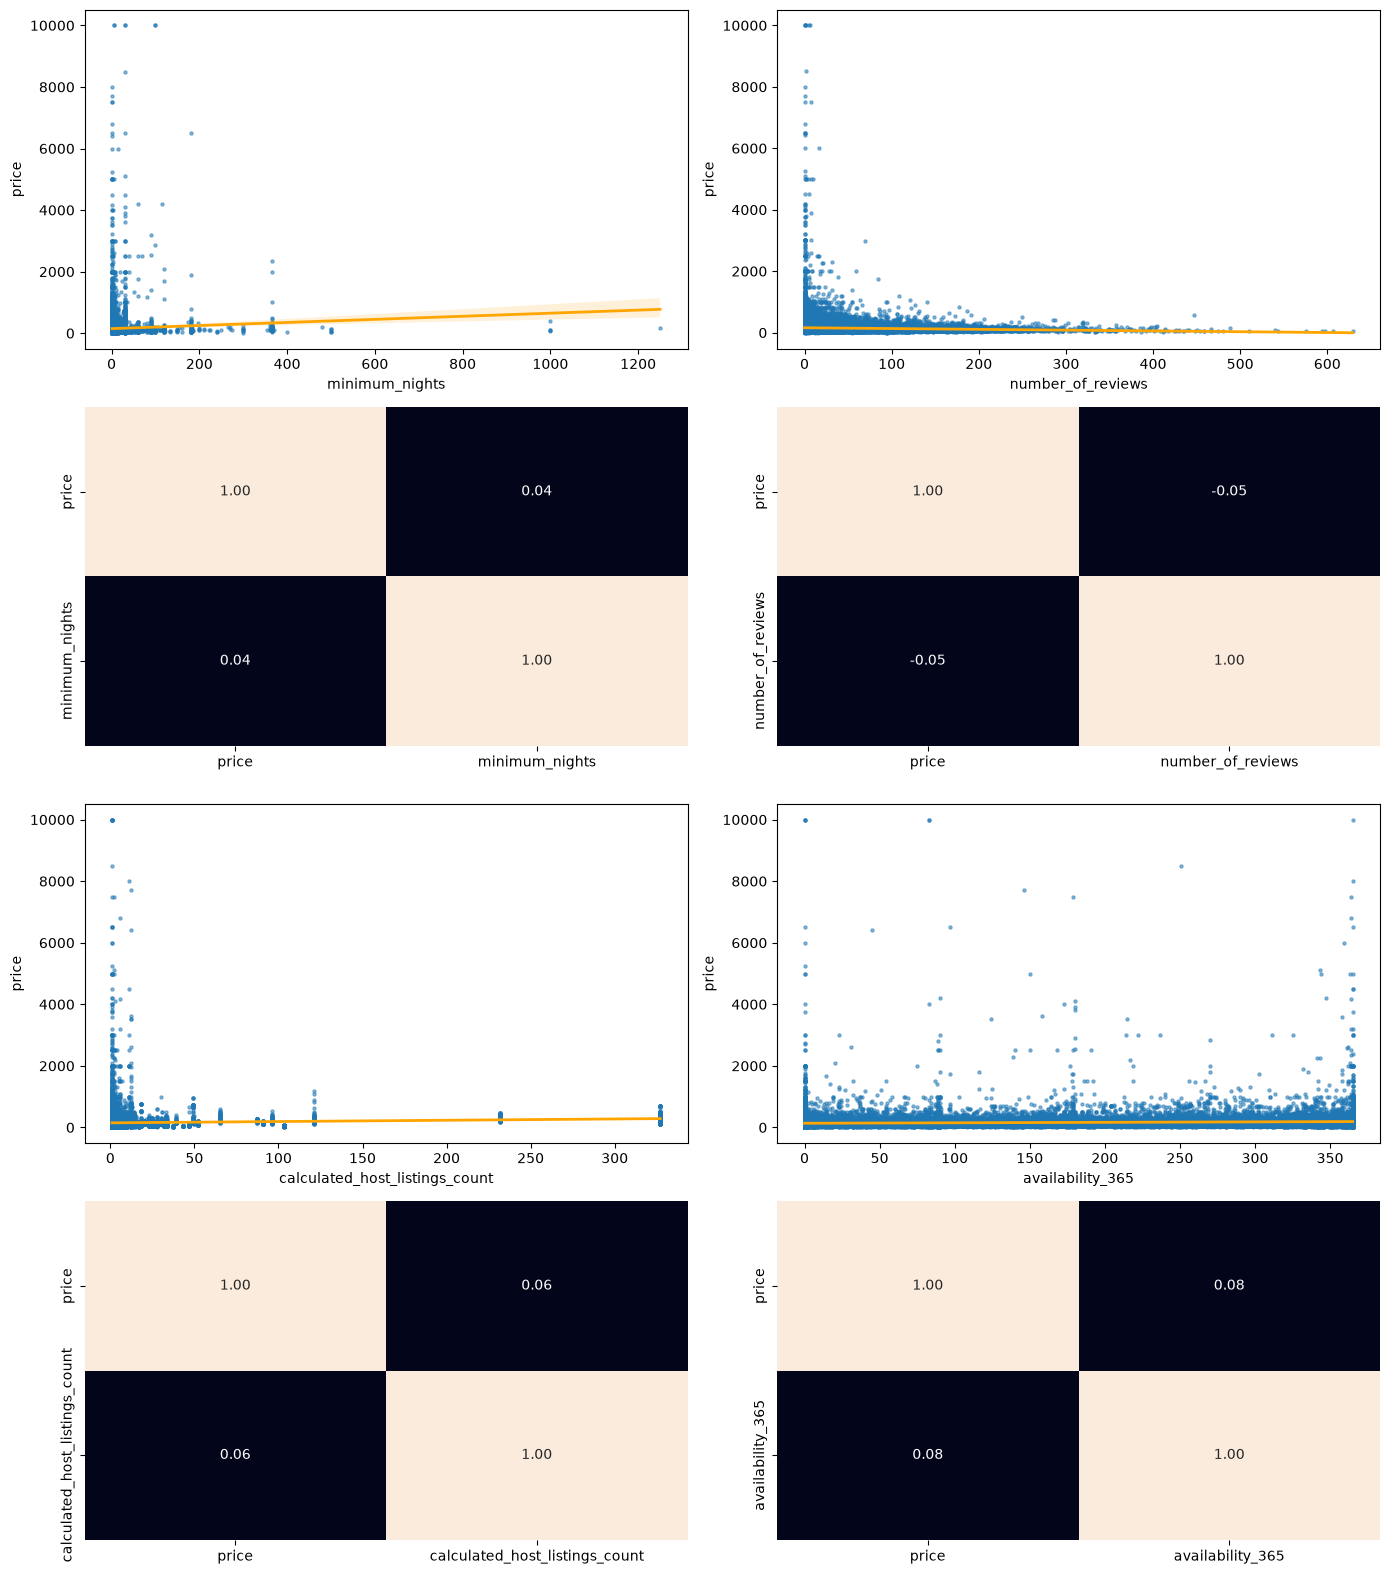

In [36]:
fig, axis = plt.subplots(4,2, figsize=(14,16))

sns.regplot(ax = axis[0,0], data = df, x = "minimum_nights", y = "price", scatter_kws = {'s': 5 ,'alpha':0.5}, line_kws = {'color':'orange', 'linewidth': 2})
sns.heatmap(df[["price","minimum_nights"]].corr(), annot=True, fmt = '.2f', ax = axis[1,0], cbar = False)

sns.regplot(ax = axis[0,1], data = df, x = "number_of_reviews", y = "price", scatter_kws = {'s': 5 ,'alpha':0.5}, line_kws = {'color':'orange', 'linewidth': 2})
sns.heatmap(df[["price","number_of_reviews"]].corr(), annot=True, fmt = '.2f', ax = axis[1,1], cbar = False)

sns.regplot(ax = axis[2,0], data = df, x = "calculated_host_listings_count", y = "price", scatter_kws = {'s': 5 ,'alpha':0.5}, line_kws = {'color':'orange', 'linewidth': 2})
sns.heatmap(df[["price","calculated_host_listings_count"]].corr(), annot=True, fmt = '.2f', ax = axis[3,0], cbar = False)

sns.regplot(ax = axis[2,1], data = df, x = "availability_365", y = "price", scatter_kws = {'s': 5 ,'alpha':0.5}, line_kws = {'color':'orange', 'linewidth': 2})
sns.heatmap(df[["price","availability_365"]].corr(), annot=True, fmt = '.2f', ax = axis[3,1], cbar = False)


plt.tight_layout()

plt.show()

Analizando los gráficos podemos determinar que:

- Por los valores de correlaciones tan bajos (**'minimum_nights'**: 0,04, **'numbers_of_reviews'**: -0,05, **'calculated_host_listings_count'**: 0,06, **'availability_365'**: 0,08) no hay relación entre el precio y cualquiera de las demás variables.
- Por lo dicho anteriormente, saber los valores de **'minimum_nights', 'numbers_of_reviews', 'calculated_host_listings_count' o 'availability_365'** no nos permite predecir el precio por noche.

---


- ***Análisis multivariante Categórico - Categórico***

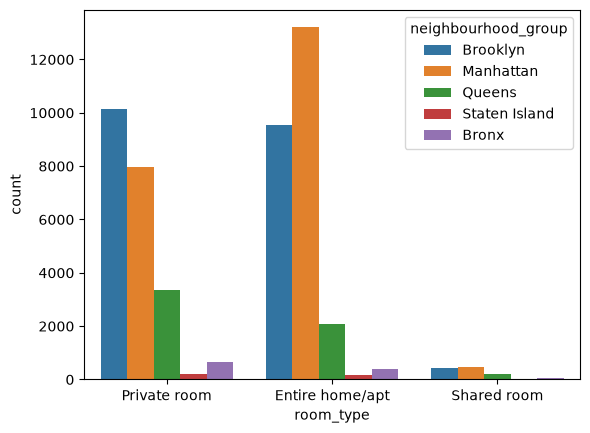

In [39]:
sns.countplot(data=df, x='room_type', hue='neighbourhood_group')

plt.show()

Analizando los gráficos podemos determinar que:

- En la categoría **'Entire home/apt'** lidera ampliamente Manhattan, superando las 12.000 publicaciones, lo que quiere decir que hay una alta oferta orientada a apartamentos completos dentro de esa zona.
- En la categoría **'Private Room'** lidera Brooklyn, con más de 10.000 publicaciones, siendo el **'neighbourhood_group'** qué más registros tiene para este tipo de alojamiento.
- En la categoría **'Shared room'** podemos observar que tenemos un volumen mínimo de publicaciones, teniendo menos del 1.000 en cada uno de los **'neighbourhood_group'**.
- Las ofertas se concentran fuertemente en Manhattan y Brooklyn, mientras que en Queens, Staten Island y Bronx, tienen una representación ampliamente menor en todas las categorías.

---

- ***Análisis multivariante Numérico - Categórico***

In [ ]:
#transformar variables categóricas a numéricas